In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [4]:
data=pd.read_csv('/content/mental_health_burnout_tech_2026.csv')

In [5]:
import copy
df=copy.deepcopy(data)

In [6]:
df.head()

,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,autonomy_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
0,1,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,...,6.1,10.0,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1
1,2,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,...,5.4,9.3,7.0,8,Mild (5-9),6,Mild (5-9),High,1,1
2,3,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,...,4.1,8.9,8.5,8,Mild (5-9),9,Mild (5-9),Severe,0,1
3,4,38,Non-binary,USA,Software Engineer,Lead,14,1.2,Mid (201-1000),SaaS / Cloud,...,7.3,10.0,10.0,14,Moderate (10-14),11,Moderate (10-14),Severe,0,1
4,5,22,Non-binary,France,ML Engineer,Junior,0,3.0,Small (51-200),AI / ML Startup,...,4.4,7.7,5.4,8,Mild (5-9),0,Minimal (0-4),Moderate,1,0


In [7]:
df.tail()

,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,autonomy_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
99995,99996,38,Female,USA,Data Scientist,Senior,17,1.9,Startup (1-50),Gaming,...,4.0,8.1,6.2,1,None (0-4),0,Minimal (0-4),High,0,1
99996,99997,36,Female,India,Product Manager,Manager,17,1.4,Small (51-200),SaaS / Cloud,...,5.6,10.0,6.5,10,Moderate (10-14),5,Mild (5-9),High,0,0
99997,99998,42,Male,USA,Software Engineer,Mid,22,0.7,Large (1001-5000),Cybersecurity,...,3.8,2.5,0.6,7,Mild (5-9),1,Minimal (0-4),Low,0,0
99998,99999,30,Male,UK,Data Scientist,Senior,7,5.6,Small (51-200),E-commerce,...,4.6,4.8,3.8,10,Moderate (10-14),0,Minimal (0-4),Moderate,1,0
99999,100000,36,Male,Netherlands,ML Engineer,Mid,13,1.1,Large (1001-5000),SaaS / Cloud,...,4.4,5.3,4.1,2,None (0-4),2,Minimal (0-4),Moderate,0,0


In [8]:
print("Shape:",df.shape)

Shape: (100000, 36)


In [9]:
df.columns

Index(['employee_id', 'age', 'gender', 'country', 'job_role',
       'seniority_level', 'years_experience', 'years_at_company',
       'company_size', 'industry', 'work_mode', 'salary_usd',
       'work_hours_per_week', 'meetings_per_day', 'team_size',
       'sleep_hours_per_night', 'exercise_days_per_week',
       'vacation_days_taken', 'therapy_access', 'uses_therapy',
       'ai_tools_daily', 'manager_support_score', 'work_life_balance_score',
       'job_satisfaction_score', 'social_support_score',
       'deadline_pressure_score', 'autonomy_score', 'stress_score',
       'burnout_score', 'phq9_score', 'phq9_category', 'gad7_score',
       'gad7_category', 'burnout_level', 'seeks_mental_health_support',
       'job_change_intention'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   employee_id                  100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   country                      100000 non-null  object 
 4   job_role                     100000 non-null  object 
 5   seniority_level              100000 non-null  object 
 6   years_experience             100000 non-null  int64  
 7   years_at_company             100000 non-null  float64
 8   company_size                 100000 non-null  object 
 9   industry                     100000 non-null  object 
 10  work_mode                    100000 non-null  object 
 11  salary_usd                   100000 non-null  int64  
 12  work_hours_per_week          100000 non-null  int64  
 13  

**Drop the identifier employee_id**

In [11]:
df=df.drop(columns=['employee_id'])

In [12]:
df.shape

(100000, 35)

In [13]:
df.isnull().sum().sum()

np.int64(0)

# **Exploring demographics features**

**Univariate analysis**

In [14]:
print("Highest age is: ",df['age'].max())
print("Lowest age is: ",df['age'].min())
print("Average age is: ",df['age'].mean())

Highest age is:  55
Lowest age is:  22
Average age is:  31.30567


Text(0, 0.5, 'Density')

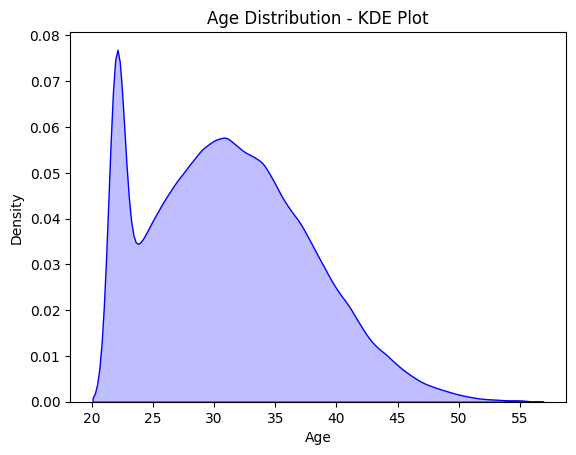

In [15]:
sns.kdeplot(df['age'], fill=True, color='blue')

plt.title("Age Distribution - KDE Plot")
plt.xlabel("Age")
plt.ylabel("Density")

In [16]:
young_employees = df[df['age'] < 25]
middle_aged_employees = df[(df['age'] >= 25) & (df['age'] <40)]
old_employees = df[df['age'] >= 40]

In [17]:
print(len(young_employees))
print(len(middle_aged_employees))
print(len(old_employees))

17748
70994
11258


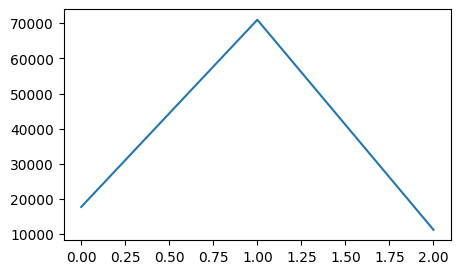

In [18]:
plt.figure(figsize=(5, 3))

plt.plot([len(young_employees),len(middle_aged_employees),len(old_employees)])

In [19]:
conditions=[
    df['age']<25,
    (df['age']>=25) & (df['age']<40),
    df['age']>=40
]

choices=['Young','Middle-aged','Old']
df['age_category']=np.select(conditions,choices,default=df['age'])

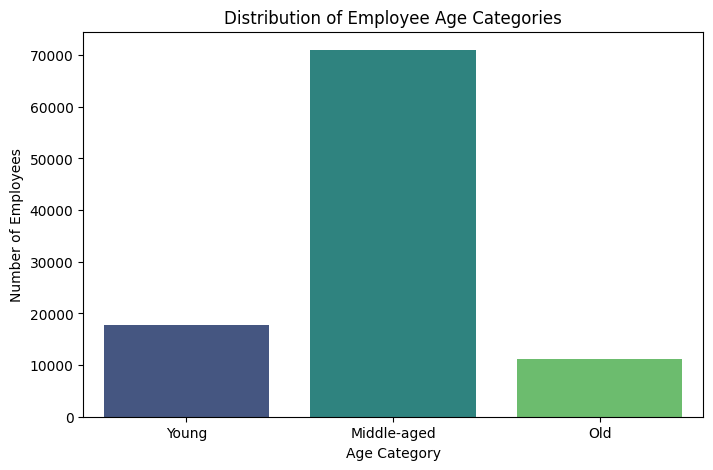

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df['age_category'], data=df, order=['Young', 'Middle-aged', 'Old'], palette='viridis')
plt.title('Distribution of Employee Age Categories')
plt.xlabel('Age Category')
plt.ylabel('Number of Employees')
plt.show()

In [21]:
mapping = {'Young': 0, 'Middle-aged': 1, 'Old': 2}
df['age_group_encoded'] = df['age_category'].map(mapping)

In [22]:
df[['age','age_category','age_group_encoded']].head()

,age,age_category,age_group_encoded
0,33,Middle-aged,1
1,24,Young,0
2,36,Middle-aged,1
3,38,Middle-aged,1
4,22,Young,0


In [23]:
df['gender'].value_counts()

,count
gender,
Male,65243
Female,29759
Non-binary,3994
Prefer not to say,1004


In [24]:
conditions=[
    df['gender']=='Male',
    df['gender']=='Female',
    (df['gender']=='Non-binary') | (df['gender']=='Prefer not to say')
]
choices=['M','F','Other']

df['gender_category']=np.select(conditions,choices,default=df['gender'])

In [25]:
df[['gender','gender_category']].head()

,gender,gender_category
0,Male,M
1,Non-binary,Other
2,Prefer not to say,Other
3,Non-binary,Other
4,Non-binary,Other


In [26]:
mapping = {'M': 0, 'F': 1, 'Other': 2}
df['gender_encoded'] = df['gender_category'].map(mapping)

In [27]:
df[['gender','gender_category','gender_encoded']].head()

,gender,gender_category,gender_encoded
0,Male,M,0
1,Non-binary,Other,2
2,Prefer not to say,Other,2
3,Non-binary,Other,2
4,Non-binary,Other,2


In [28]:
df['country'].value_counts()

,count
country,
USA,31966
India,21998
UK,9939
Canada,7940
Germany,7099
Australia,6169
Brazil,4050
Netherlands,3956
Singapore,3947


In [29]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['country_encoded'] = encoder.fit_transform(df['country'])

In [30]:
df[['country','country_encoded']].head()

,country,country_encoded
0,India,5
1,USA,9
2,USA,9
3,USA,9
4,France,3


**Bivariate analysis**

In [31]:
pd.crosstab(df['gender_category'], df['age'])

age,22,23,24,25,26,27,28,29,30,31,...,46,47,48,49,50,51,52,53,54,55
gender_category,,,,,,,,,,,,,,,,,,,,,
F,3390,906,1028,1184,1303,1489,1472,1602,1654,1794,...,185,119,82,71,41,23,14,15,10,10
M,7429,1875,2222,2576,2902,3129,3407,3665,3768,3761,...,369,271,212,152,102,72,38,34,13,26
Other,566,144,188,206,230,220,284,272,284,291,...,36,20,22,8,10,5,3,1,0,3


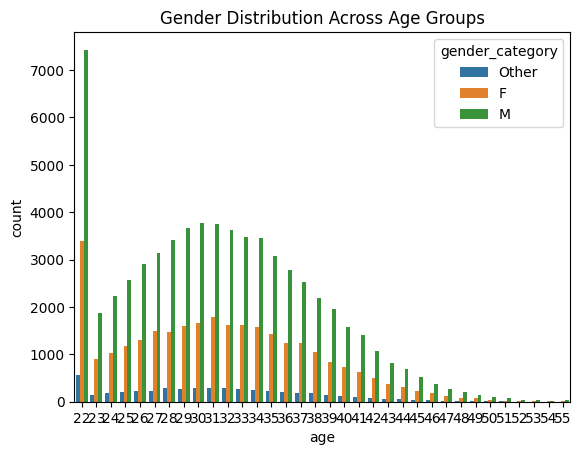

In [32]:
sns.countplot(x='age', hue='gender_category', data=df)
plt.title("Gender Distribution Across Age Groups")
plt.show()

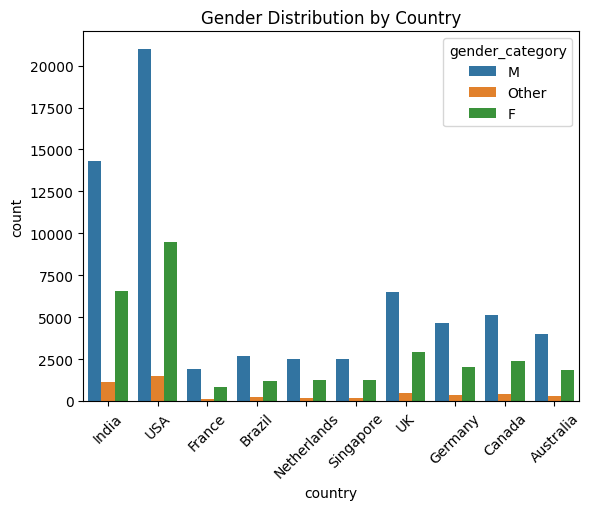

In [33]:
sns.countplot(x='country', hue='gender_category', data=df)
plt.title("Gender Distribution by Country")
plt.xticks(rotation=45)
plt.show()

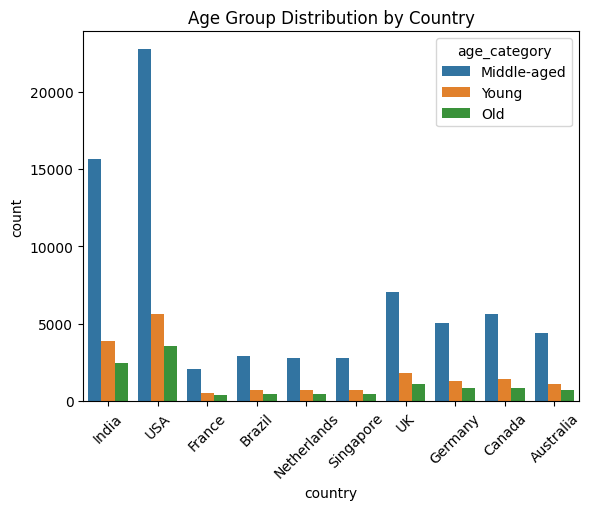

In [34]:
sns.countplot(x='country', hue='age_category', data=df)
plt.title("Age Group Distribution by Country")
plt.xticks(rotation=45)
plt.show()

# **Exploring work related features**

**Univariate analysis**

In [35]:
df['job_role'].value_counts()

,count
job_role,
Software Engineer,20080
Data Scientist,12029
ML Engineer,10114
Data Analyst,8028
Backend Developer,7996
Frontend Developer,7970
Product Manager,7965
DevOps Engineer,7949
Full Stack Developer,6907


In [36]:
conditions=[
    df['job_role'].isin(['Software Engineer','Backend Developer','Frontend Developer','Full Stack Developer']),
    df['job_role'].isin(['Data Analyst','Data Scientist','ML Engineer']),
    df['job_role'].isin(['Product Manager','DevOps Engineer','Cybersecurity Engineer','Cloud Engineer','QA Engineer'])
]

choices=['Development','Data','Other']

df['job_category']=np.select(conditions,choices,default=df['job_role'])

df['job_role_categorized']=np.select(conditions,choices,default=df['job_role'])

In [37]:
df[['job_role','job_role_categorized']].head(10)

,job_role,job_role_categorized
0,Software Engineer,Development
1,Full Stack Developer,Development
2,Software Engineer,Development
3,Software Engineer,Development
4,ML Engineer,Data
5,Data Analyst,Data
6,Data Analyst,Data
7,DevOps Engineer,Other
8,Software Engineer,Development
9,Product Manager,Other


In [39]:
mapping={'Development':0,'Data':1,'Other':2}
df['job_role_encoded']=df['job_role_categorized'].map(mapping)

In [40]:
df[['job_role','job_role_categorized','job_role_encoded']].head(10)

,job_role,job_role_categorized,job_role_encoded
0,Software Engineer,Development,0
1,Full Stack Developer,Development,0
2,Software Engineer,Development,0
3,Software Engineer,Development,0
4,ML Engineer,Data,1
5,Data Analyst,Data,1
6,Data Analyst,Data,1
7,DevOps Engineer,Other,2
8,Software Engineer,Development,0
9,Product Manager,Other,2


In [41]:
df['seniority_level'].head()

,seniority_level
0,Lead
1,Manager
2,Lead
3,Lead
4,Junior


In [42]:
df['seniority_level'].value_counts()

,count
seniority_level,
Mid,28092
Senior,24852
Junior,20230
Lead,11928
Manager,9915
Principal,4983


In [43]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['seniority_level_encoded'] = encoder.fit_transform(df['seniority_level'])

In [44]:
df[['seniority_level','seniority_level_encoded']].head(10)

,seniority_level,seniority_level_encoded
0,Lead,1
1,Manager,2
2,Lead,1
3,Lead,1
4,Junior,0
5,Principal,4
6,Junior,0
7,Mid,3
8,Mid,3
9,Mid,3


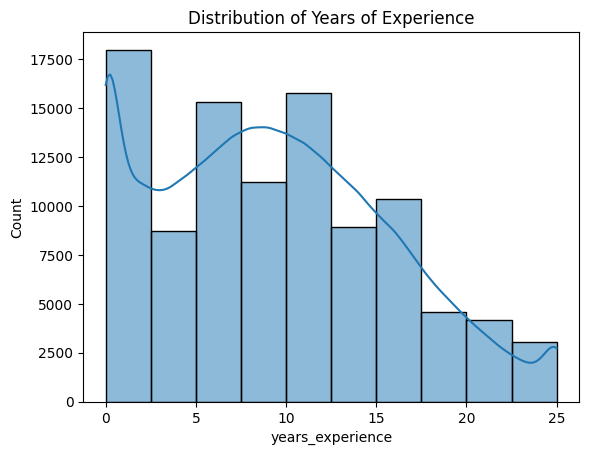

In [45]:
sns.histplot(df['years_experience'], bins=10, kde=True)
plt.title("Distribution of Years of Experience")
plt.show()

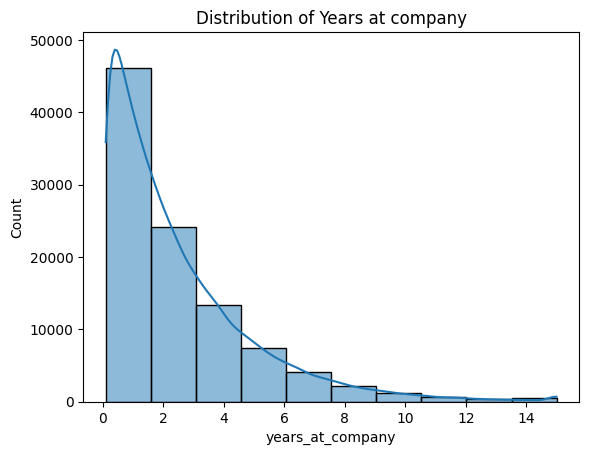

In [46]:
sns.histplot(df['years_at_company'], bins=10, kde=True)
plt.title("Distribution of Years at company")
plt.show()

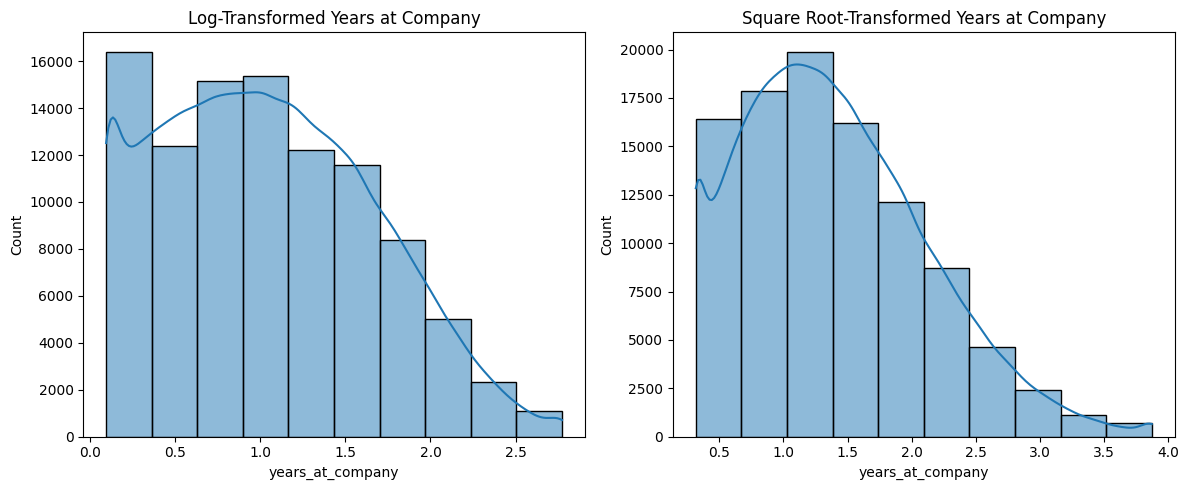

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Log transformation
sns.histplot(np.log1p(df['years_at_company']), bins=10, kde=True, ax=axes[0])
axes[0].set_title("Log-Transformed Years at Company")

# Square root transformation
sns.histplot(np.sqrt(df['years_at_company']), bins=10, kde=True, ax=axes[1])
axes[1].set_title("Square Root-Transformed Years at Company")

plt.tight_layout()
plt.show()

In [48]:
df['years_at_company_transformed']=np.sqrt(df['years_at_company'])

In [49]:
df[['years_at_company','years_at_company_transformed']].head()

,years_at_company,years_at_company_transformed
0,6.4,2.529822
1,5.7,2.387467
2,5.6,2.366432
3,1.2,1.095445
4,3.0,1.732051


In [50]:
df['company_size'].value_counts()

,count
company_size,
Mid (201-1000),25062
Large (1001-5000),22027
Startup (1-50),19771
Small (51-200),18067
Enterprise (5000+),15073


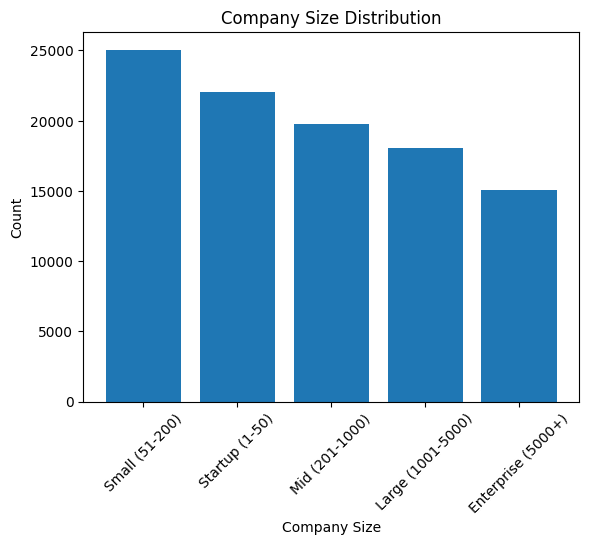

In [51]:
plt.bar(df['company_size'].unique(), df['company_size'].value_counts())
plt.xlabel('Company Size')
plt.ylabel('Count')
plt.title('Company Size Distribution')
plt.xticks(rotation=45)
plt.show()

In [52]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['company_size_encoded'] = encoder.fit_transform(df['company_size'])

In [53]:
df['company_size_encoded'].value_counts()

,count
company_size_encoded,
2,25062
1,22027
4,19771
3,18067
0,15073


In [54]:
df['industry'].value_counts()

,count
industry,
SaaS / Cloud,19957
Fintech,15064
E-commerce,12057
AI / ML Startup,11957
Healthcare Tech,10004
Cybersecurity,7900
Consulting,7012
Enterprise Software,6098
Gaming,5936


In [55]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['industry_encoded'] = encoder.fit_transform(df['industry'])

In [56]:
df['industry_encoded'].value_counts()

,count
industry_encoded,
8,19957
5,15064
3,12057
0,11957
7,10004
2,7900
1,7012
4,6098
6,5936


In [57]:
df['work_mode'].value_counts()

,count
work_mode,
Hybrid,39856
Remote,34936
On-site,25208


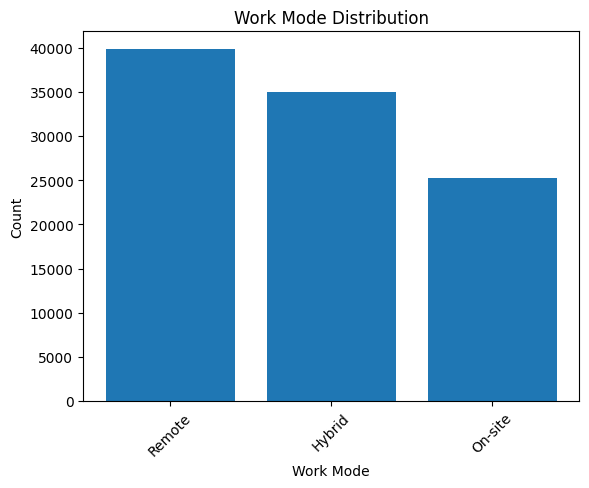

In [58]:
plt.bar(df['work_mode'].unique(), df['work_mode'].value_counts())
plt.xlabel('Work Mode')
plt.ylabel('Count')
plt.title('Work Mode Distribution')
plt.xticks(rotation=45)
plt.show()

In [59]:
df['work_mode_encoded'] = encoder.fit_transform(df['work_mode'])

In [60]:
df['work_mode_encoded'].value_counts()

,count
work_mode_encoded,
0,39856
2,34936
1,25208


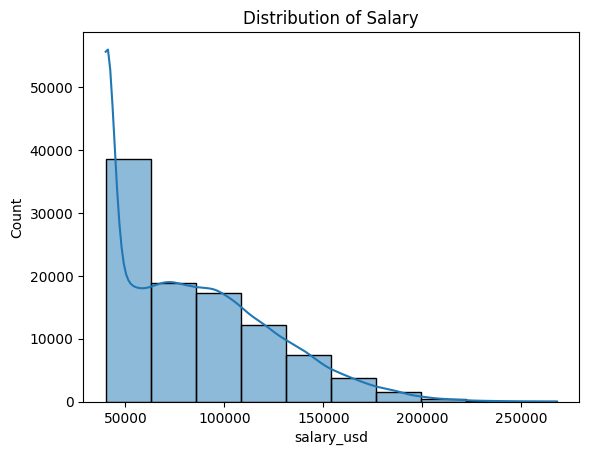

In [61]:
sns.histplot(df['salary_usd'],bins=10,kde=True)
plt.title("Distribution of Salary")
plt.show()

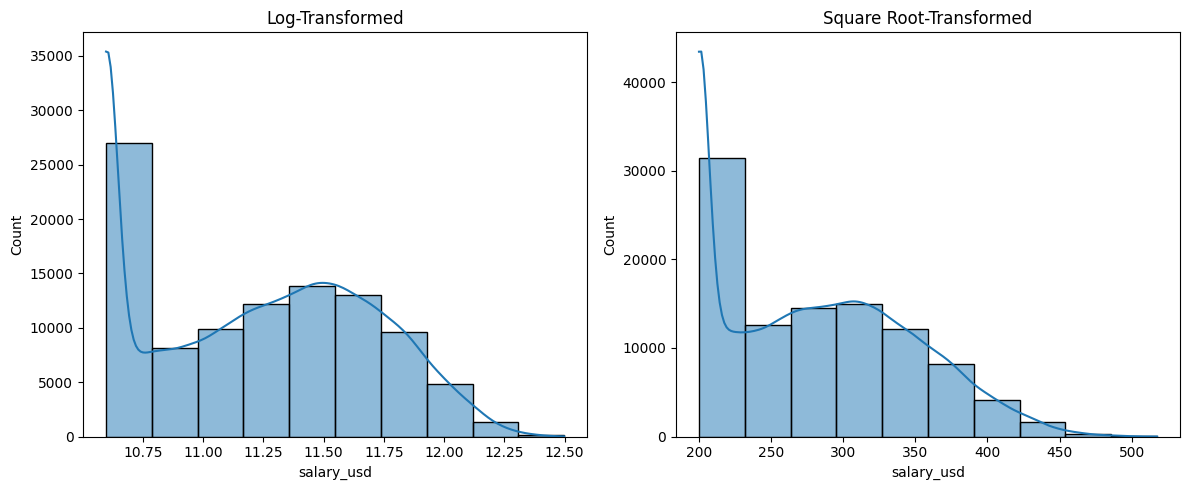

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Log transformation
sns.histplot(np.log1p(df['salary_usd']), bins=10, kde=True, ax=axes[0])
axes[0].set_title("Log-Transformed")

# Square root transformation
sns.histplot(np.sqrt(df['salary_usd']), bins=10, kde=True, ax=axes[1])
axes[1].set_title("Square Root-Transformed")

plt.tight_layout()
plt.show()

In [63]:
df['salary_usd_transformed']=np.log1p(df['salary_usd'])

In [64]:
df[['salary_usd','salary_usd_transformed']].head()

,salary_usd,salary_usd_transformed
0,40000,10.596660
1,131165,11.784219
2,169180,12.038724
3,147770,11.903419
4,57228,10.954816


In [65]:
df['work_hours_per_week'].describe()

,work_hours_per_week
count,100000.000000
mean,47.104080
std,5.246902
min,35.000000
25%,44.000000
50%,47.000000
75%,51.000000
max,72.000000


<Axes: xlabel='work_hours_per_week', ylabel='Count'>

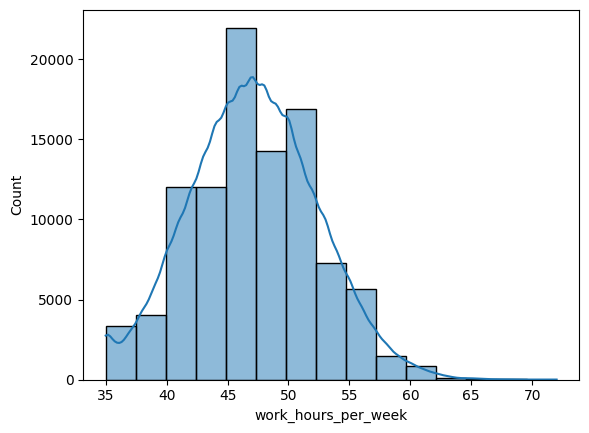

In [66]:
sns.histplot(df['work_hours_per_week'],bins=15,kde=True)

<Axes: xlabel='meetings_per_day', ylabel='Count'>

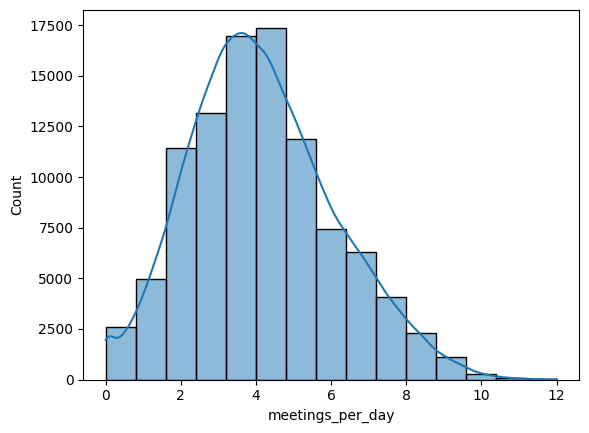

In [67]:
sns.histplot(df['meetings_per_day'],bins=15,kde=True)

In [68]:
df['team_size'].describe()

,team_size
count,100000.000000
mean,18.009650
std,12.607473
min,2.000000
25%,8.000000
50%,16.000000
75%,25.000000
max,59.000000


<Axes: xlabel='team_size', ylabel='Count'>

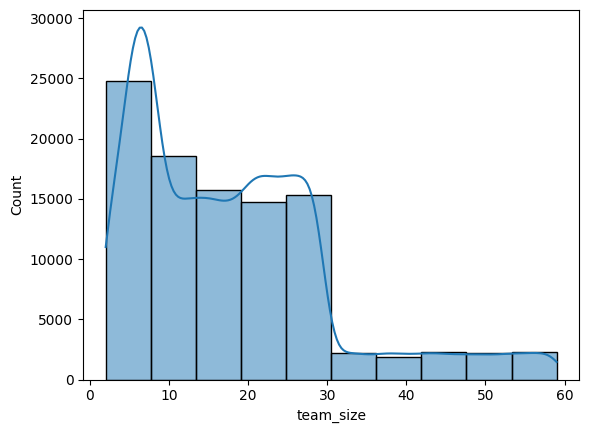

In [69]:
sns.histplot(df['team_size'],bins=10,kde=True)

In [70]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

df['team_size_scaled'] = scaler.fit_transform(df[['team_size']])

<Axes: xlabel='team_size_scaled', ylabel='Count'>

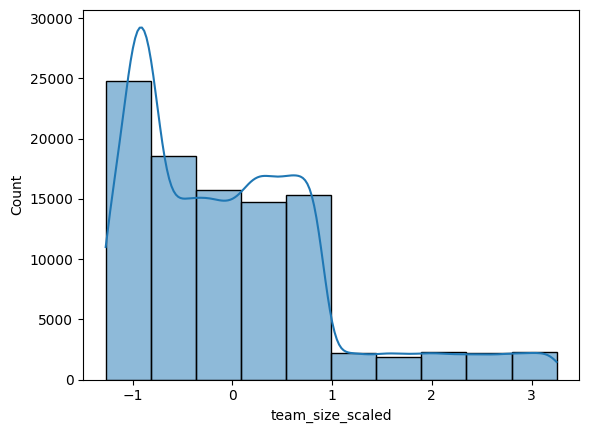

In [71]:
sns.histplot(df['team_size_scaled'],bins=10,kde=True)

In [72]:
df[['team_size','team_size_scaled']].head()

,team_size,team_size_scaled
0,19,0.078553
1,7,-0.873268
2,27,0.713100
3,12,-0.476676
4,8,-0.793950


**Bivariate analysis**

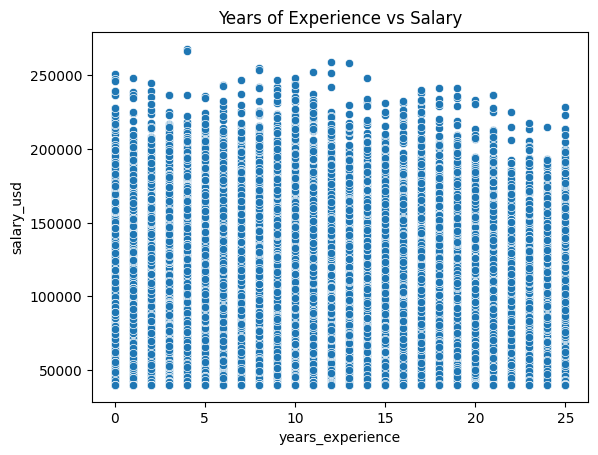

,years_experience,years_at_company,salary_usd,work_hours_per_week,meetings_per_day,team_size
years_experience,1.000000,0.002939,0.001682,0.003825,0.000344,-0.000039
years_at_company,0.002939,1.000000,-0.005711,-0.001678,-0.002469,-0.004253
salary_usd,0.001682,-0.005711,1.000000,0.145491,0.223219,0.093621
work_hours_per_week,0.003825,-0.001678,0.145491,1.000000,0.189173,0.000410
meetings_per_day,0.000344,-0.002469,0.223219,0.189173,1.000000,0.003443
team_size,-0.000039,-0.004253,0.093621,0.000410,0.003443,1.000000


In [73]:
sns.scatterplot(x='years_experience', y='salary_usd', data=df)
plt.title("Years of Experience vs Salary")
plt.show()

df[['years_experience','years_at_company','salary_usd','work_hours_per_week','meetings_per_day','team_size']].corr()


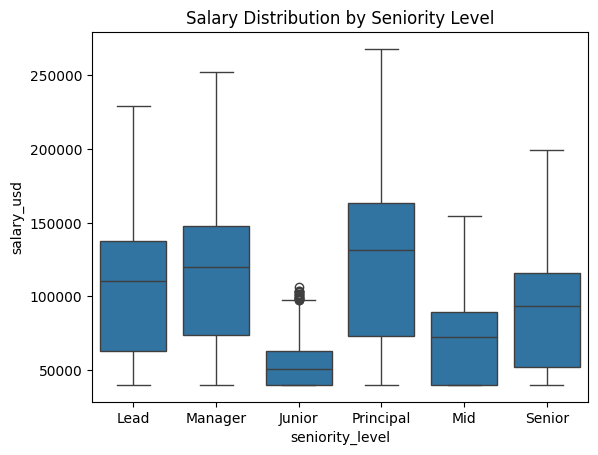

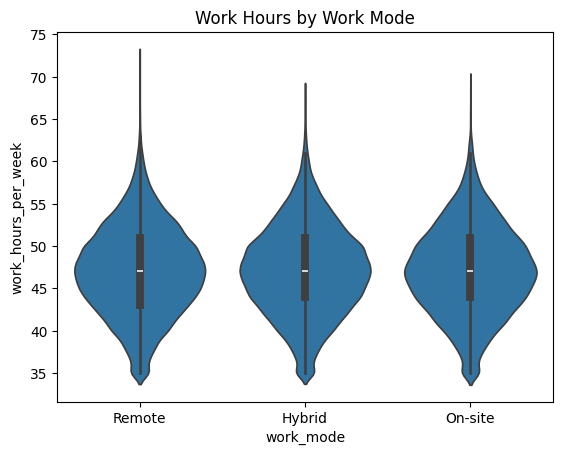

In [74]:
sns.boxplot(x='seniority_level', y='salary_usd', data=df)
plt.title("Salary Distribution by Seniority Level")
plt.show()

sns.violinplot(x='work_mode', y='work_hours_per_week', data=df)
plt.title("Work Hours by Work Mode")
plt.show()


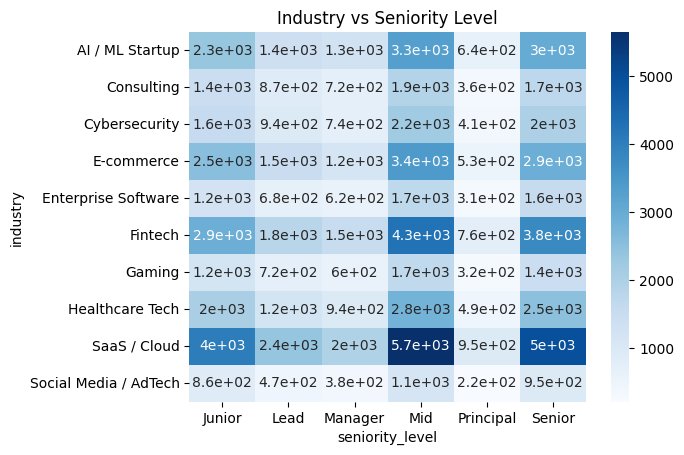

In [75]:
pd.crosstab(df['job_role'], df['work_mode'])

sns.heatmap(pd.crosstab(df['industry'], df['seniority_level']), annot=True, cmap="Blues")
plt.title("Industry vs Seniority Level")
plt.show()


# **Exploring Lifestyle features**

**Univariate analysis**

<Axes: xlabel='sleep_hours_per_night', ylabel='Count'>

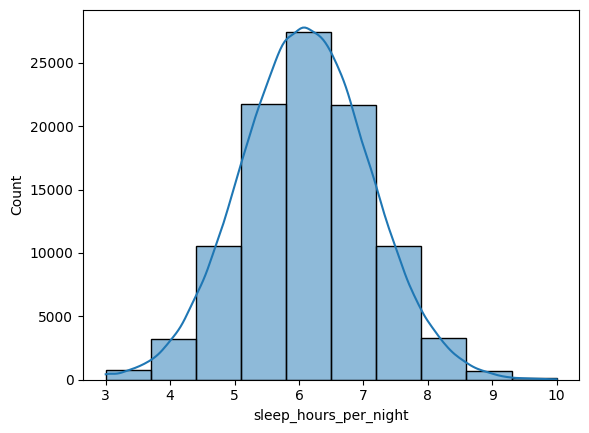

In [76]:
sns.histplot(df['sleep_hours_per_night'],bins=10,kde=True)

<Axes: xlabel='exercise_days_per_week', ylabel='Count'>

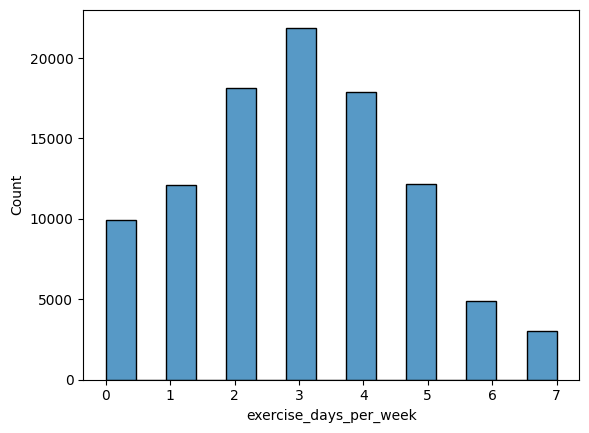

In [77]:
sns.histplot(df['exercise_days_per_week'],bins=15)

<Axes: xlabel='vacation_days_taken', ylabel='Count'>

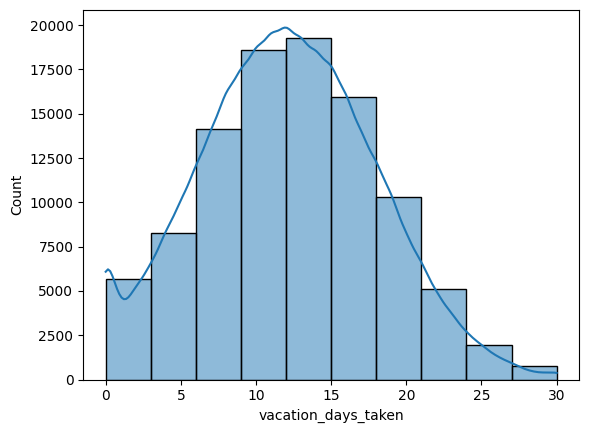

In [78]:
sns.histplot(df['vacation_days_taken'],bins=10,kde=True)

In [79]:
df['therapy_access'].value_counts()

,count
therapy_access,
0,65938
1,34062


In [80]:
df['uses_therapy'].value_counts()

,count
uses_therapy,
0,84815
1,15185


In [81]:
df['ai_tools_daily'].value_counts()

,count
ai_tools_daily,
1,73006
0,26994


**Bivariate analysis**

uses_therapy        0      1
therapy_access              
0               65938      0
1               18877  15185


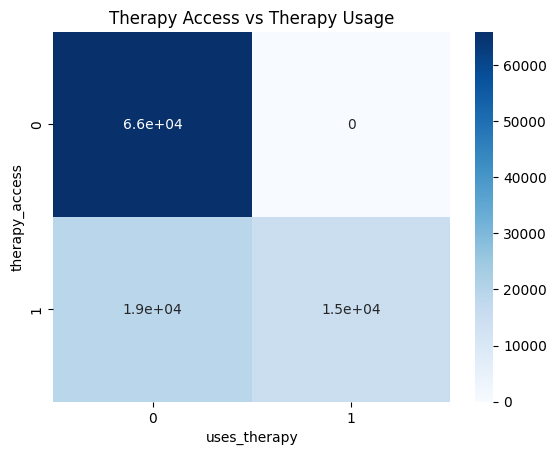

In [82]:
ct = pd.crosstab(df['therapy_access'], df['uses_therapy'])
print(ct)
sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("Therapy Access vs Therapy Usage")
plt.show()

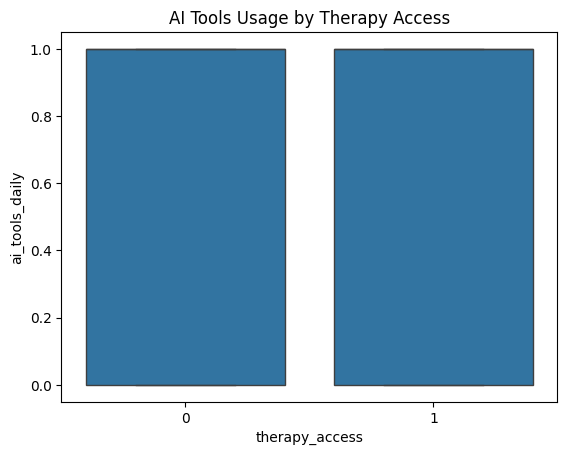

In [83]:
sns.boxplot(x='therapy_access', y='ai_tools_daily', data=df)
plt.title("AI Tools Usage by Therapy Access")
plt.show()

# **Exploring Work Place culture**

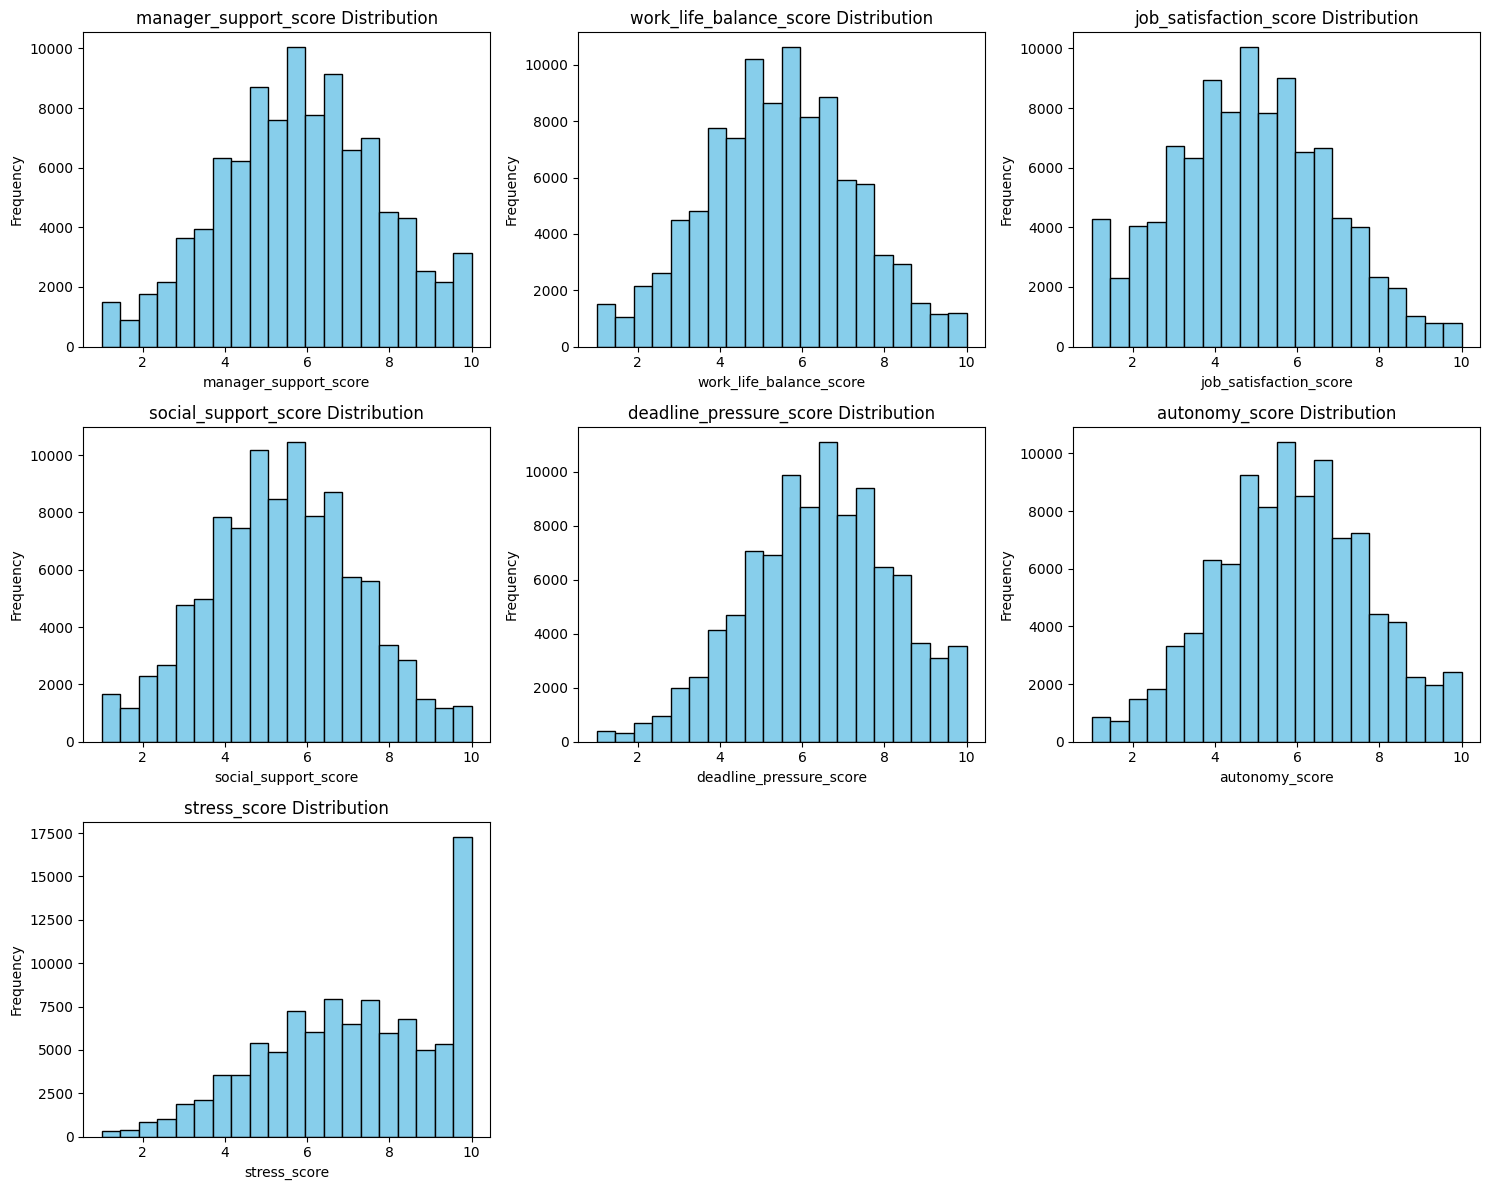

In [91]:
import matplotlib.pyplot as plt

# Features to plot
features = [
    'manager_support_score',
    'work_life_balance_score',
    'job_satisfaction_score',
    'social_support_score',
    'deadline_pressure_score',
    'autonomy_score',
    'stress_score'
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")


for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# **Exploring Clinical Scores**

<Axes: xlabel='burnout_score', ylabel='Count'>

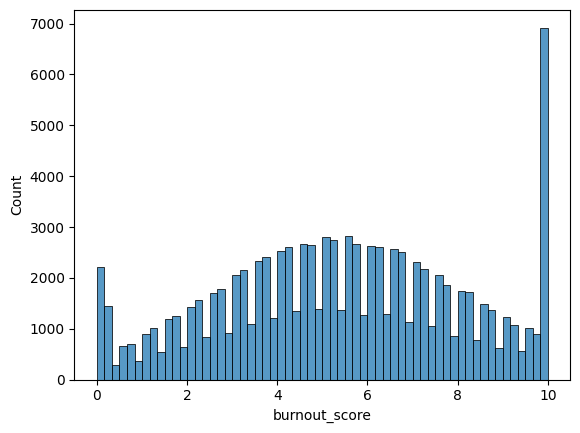

In [99]:
sns.histplot(df['burnout_score'])

In [101]:
df['burnout_score'].describe()

,burnout_score
count,100000.000000
mean,5.401675
std,2.668425
min,0.000000
25%,3.500000
50%,5.400000
75%,7.400000
max,10.000000


<Axes: xlabel='phq9_score', ylabel='Count'>

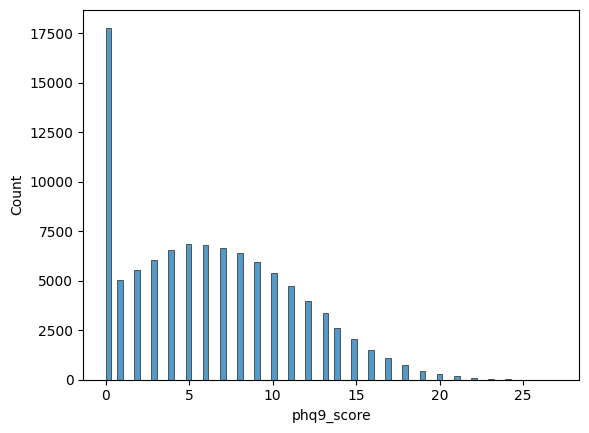

In [100]:
sns.histplot(df['phq9_score'])

In [102]:
df['phq9_category'].value_counts()

,count
phq9_category,
None (0-4),40918
Mild (5-9),32611
Moderate (10-14),20133
Moderately Severe (15-19),5773
Severe (20-27),565


In [104]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['phq9_category_encoded'] = encoder.fit_transform(df['phq9_category'])

In [105]:
print(df['phq9_category'].value_counts())
print(df['phq9_category_encoded'].value_counts())

phq9_category
None (0-4)                   40918
Mild (5-9)                   32611
Moderate (10-14)             20133
Moderately Severe (15-19)     5773
Severe (20-27)                 565
Name: count, dtype: int64
phq9_category_encoded
3    40918
0    32611
1    20133
2     5773
4      565
Name: count, dtype: int64


<Axes: xlabel='gad7_score', ylabel='Count'>

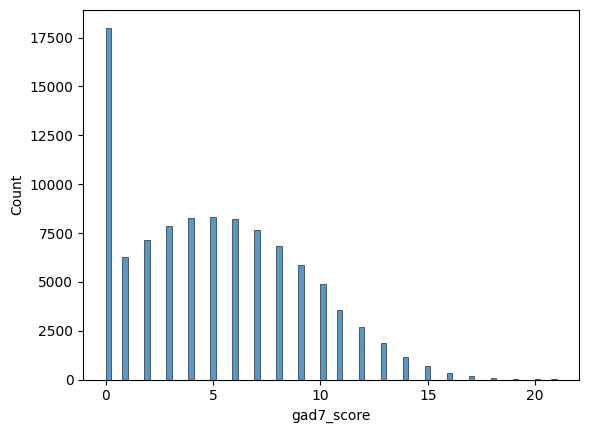

In [107]:
sns.histplot(df['gad7_score'])

In [109]:
df['gad7_category'].value_counts()

,count
gad7_category,
Minimal (0-4),47532
Mild (5-9),36912
Moderate (10-14),14191
Severe (15-21),1365


In [110]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['gad7_category_encoded'] = encoder.fit_transform(df['gad7_category'])

In [111]:
print(df['gad7_category'].value_counts())
print(df['gad7_category_encoded'].value_counts())

gad7_category
Minimal (0-4)       47532
Mild (5-9)          36912
Moderate (10-14)    14191
Severe (15-21)       1365
Name: count, dtype: int64
gad7_category_encoded
1    47532
0    36912
2    14191
3     1365
Name: count, dtype: int64


In [113]:
df['seeks_mental_health_support'].value_counts()

,count
seeks_mental_health_support,
0,50211
1,49789


<Axes: xlabel='seeks_mental_health_support', ylabel='count'>

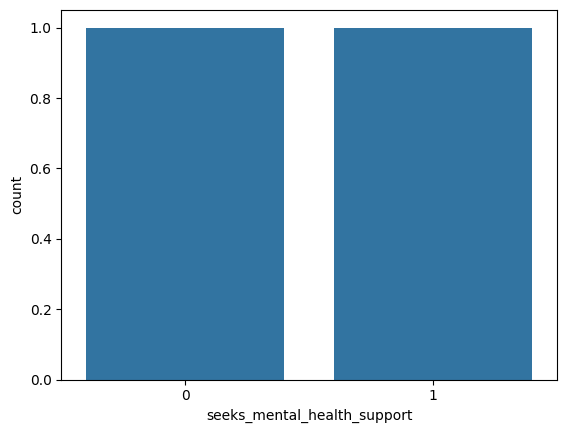

In [116]:
sns.countplot(df['seeks_mental_health_support'].value_counts())

In [117]:
df['job_change_intention'].value_counts()

,count
job_change_intention,
0,67998
1,32002


<Axes: xlabel='job_change_intention', ylabel='count'>

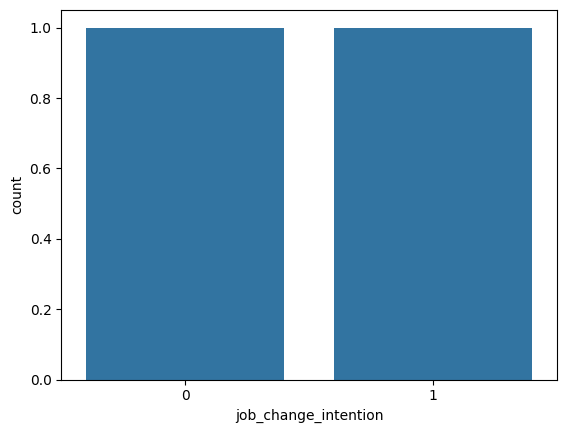

In [118]:
sns.countplot(df['job_change_intention'].value_counts())

# **Target feature analysis**

In [119]:
df['burnout_level'].value_counts()

,count
burnout_level,
Severe,28576
Moderate,26255
Low,25807
High,19362


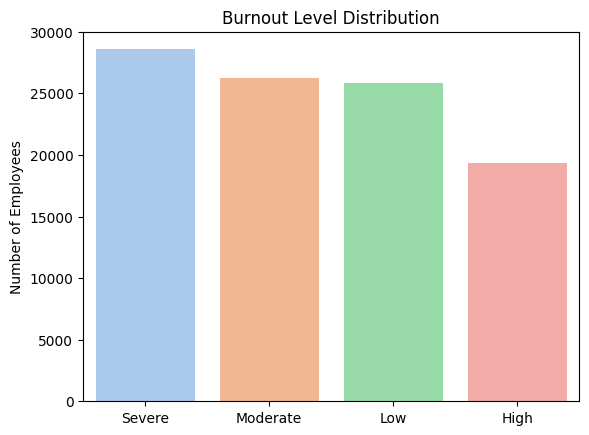

In [120]:
burnout_counts = {
    'Severe': 28576,
    'Moderate': 26255,
    'Low': 25807,
    'High': 19362
}

sns.barplot(x=list(burnout_counts.keys()), y=list(burnout_counts.values()), palette="pastel")
plt.title("Burnout Level Distribution")
plt.ylabel("Number of Employees")
plt.show()


In [122]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['burnout_level_encoded'] = encoder.fit_transform(df['burnout_level'])


In [123]:
df['burnout_level_encoded'].value_counts()

,count
burnout_level_encoded,
3,28576
2,26255
1,25807
0,19362


# **Model building**

In [124]:
df.columns

Index(['age', 'gender', 'country', 'job_role', 'seniority_level',
       'years_experience', 'years_at_company', 'company_size', 'industry',
       'work_mode', 'salary_usd', 'work_hours_per_week', 'meetings_per_day',
       'team_size', 'sleep_hours_per_night', 'exercise_days_per_week',
       'vacation_days_taken', 'therapy_access', 'uses_therapy',
       'ai_tools_daily', 'manager_support_score', 'work_life_balance_score',
       'job_satisfaction_score', 'social_support_score',
       'deadline_pressure_score', 'autonomy_score', 'stress_score',
       'burnout_score', 'phq9_score', 'phq9_category', 'gad7_score',
       'gad7_category', 'burnout_level', 'seeks_mental_health_support',
       'job_change_intention', 'age_category', 'age_group_encoded',
       'gender_category', 'gender_encoded', 'country_encoded', 'job_category',
       'job_role_categorized', 'job_role_encoded', 'seniority_level_encoded',
       'years_at_company_transformed', 'company_size_encoded',
       'industry

In [125]:
selected_features = [
    'age_group_encoded','gender_encoded','country_encoded','job_role_encoded',
    'seniority_level_encoded','years_experience','years_at_company_transformed',
    'company_size_encoded','industry_encoded','work_mode_encoded','salary_usd_transformed',
    'team_size_scaled','sleep_hours_per_night','exercise_days_per_week','vacation_days_taken',
    'therapy_access','uses_therapy','ai_tools_daily','manager_support_score',
    'work_life_balance_score','job_satisfaction_score','social_support_score',
    'deadline_pressure_score','autonomy_score','stress_score','burnout_score',
    'phq9_score','gad7_score'
]

target = 'burnout_level_encoded'


In [126]:
from sklearn.model_selection import train_test_split

X = df[selected_features]
y = df['burnout_level_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [128]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Support Vector Machine": SVC(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "Naive Bayes": GaussianNB()
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    results[name] = acc

results

{'Logistic Regression': 0.9939,
 'Random Forest': 0.9999,
 'Gradient Boosting': 1.0,
 'AdaBoost': 0.4517,
 'Support Vector Machine': 0.98145,
 'XGBoost': 1.0,
 'Naive Bayes': 0.92275}

In [129]:
from sklearn.metrics import classification_report

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))



Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3873
           1       0.99      0.99      0.99      5161
           2       0.99      0.99      0.99      5251
           3       1.00      1.00      1.00      5715

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3873
           1       1.00      1.00      1.00      5161
           2       1.00      1.00      1.00      5251
           3       1.00      1.00      1.00      5715

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


Gradient Boosting
              precision    recall  f1-score   support

           0       1

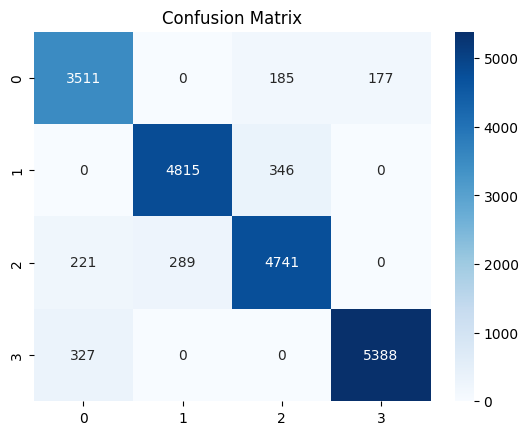

In [131]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [132]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: {scores.mean():.4f}")

Logistic Regression: 0.9887
Random Forest: 1.0000
Gradient Boosting: 1.0000
AdaBoost: 0.4517
Support Vector Machine: 0.9777
XGBoost: 1.0000
Naive Bayes: 0.9213


In [134]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Base model
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)

# Parameter distributions
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 1.5, 2, 5]
}


In [136]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,                # number of random combinations to try
    scoring='f1_weighted',    # better than accuracy for imbalanced classes
    cv=3,                     # 3-fold cross-validation
    random_state=42,
    verbose=2,
    n_jobs=-1                 # use all cores
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 1.0}
Best Score: 1.0


In [140]:
best_xgb = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    subsample=1.0,
    reg_lambda=1,
    reg_alpha=1,
    n_estimators=100,
    max_depth=9,
    learning_rate=0.1,
    gamma=1,
    colsample_bytree=1.0
)

best_xgb.fit(X_train, y_train)

y_pred = best_xgb.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3873
           1       1.00      1.00      1.00      5161
           2       1.00      1.00      1.00      5251
           3       1.00      1.00      1.00      5715

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

[[3873    0    0    0]
 [   0 5161    0    0]
 [   0    0 5251    0]
 [   0    0    0 5715]]


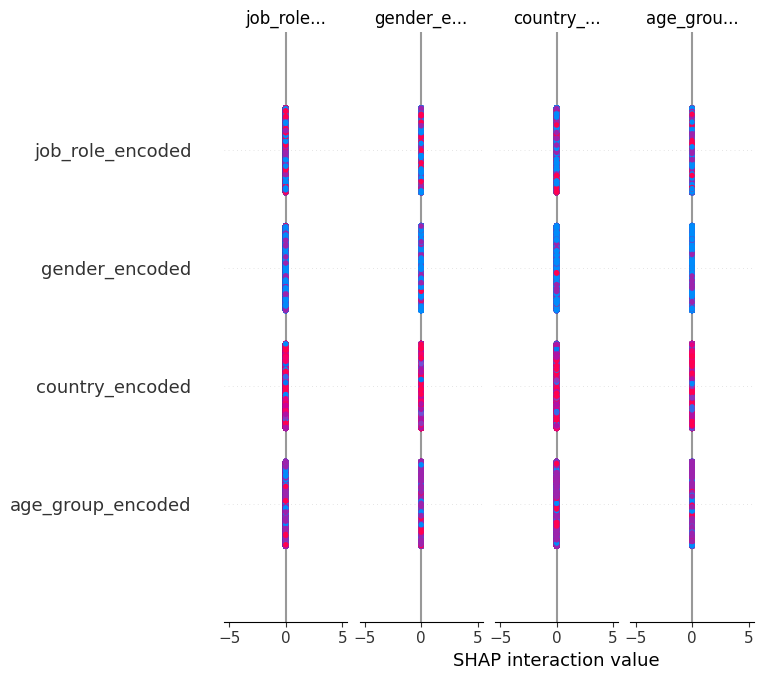

In [143]:
import shap
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=selected_features)